In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


fontRoman = pd.read_csv("ROMAN.csv")
fontArial = pd.read_csv("ARIAL.csv")
##myFont.columns


In [2]:
def analyzeFont (myFont):
    pixelColumns = [c for c in myFont.columns if c.startswith("r")]

    xRow = myFont[pixelColumns].to_numpy(dtype=np.float32)
    xRow = xRow.reshape(-1, 1, 20, 20)
    xRow = xRow/ 255

    uniLabs = myFont["m_label"].to_numpy()
    unique = sorted(myFont["m_label"].unique())

    toIndex = { label: i for i, label in enumerate(unique)}
    toUni = { i: label for label, i in toIndex.items()}
    yLabel = np.array([toIndex[label] for label in uniLabs])

    return xRow, yLabel, toIndex, toUni

In [3]:
combined = pd.concat([fontRoman, fontArial], ignore_index=True)

combinedX, combinedY, toIndex, toUni = analyzeFont(combined)

classCount = len(toIndex)

Classes: 3108
Minimum label: 0
Maximum label: 3107
First labels: [2591 2589 2581 2573 2553 2527 2522 2471 1026 1025 1024 1023 1022 1021
 1020 1019 1018 1017 1016 1015]


In [7]:
xTrain, xTest, yTrain, yTest = train_test_split(
    combinedX,
    combinedY,
    test_size=0.2,
    random_state=42,
)

In [8]:

xTrain = torch.tensor(xTrain, dtype=torch.float32)
xTest = torch.tensor(xTest, dtype=torch.float32)

yTrain = torch.tensor(yTrain, dtype=torch.long)
yTest = torch.tensor(yTest, dtype=torch.long)

trainAllData = TensorDataset(xTrain, yTrain)
testAllData = TensorDataset(xTest, yTest)

loadTrain = DataLoader(trainAllData, batch_size=64, shuffle=True)
loadTest = DataLoader(testAllData, batch_size=64, shuffle=False)

In [9]:
class LetterCNN (nn.Module):
    def __init__(self, numClass):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*5*5, 128),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(128, numClass),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x

In [10]:
model = LetterCNN(classCount)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
myEpochs = 10

for epoch in range(myEpochs):
    model.train()
    runningLoss = 0

    for images, labels, in loadTrain:
        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()
        runningLoss += loss.item()

    print (f"Epoch {epoch+1}: Loss = {runningLoss / len(loadTrain):.4f}")

Epoch 1: Loss = 6.1955
Epoch 2: Loss = 5.0550
Epoch 3: Loss = 4.2406
Epoch 4: Loss = 3.5718
Epoch 5: Loss = 3.0523
Epoch 6: Loss = 2.6611
Epoch 7: Loss = 2.3502
Epoch 8: Loss = 2.1092
Epoch 9: Loss = 1.9204
Epoch 10: Loss = 1.7718


In [12]:
model.eval()

correctness = 0
total = 0

with torch.no_grad():
    for images, labels in loadTest:
        outputs = model(images)

        _, prediction = torch.max(outputs,1)
        total += labels.size(0)
        correctness += (prediction == labels).sum().item()

accuracy = 100 * correctness/total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 61.55%


In [13]:
import matplotlib.pyplot as plt

model.eval()
correct = 0
total = 0

misses = []

with torch.no_grad():
    for images, labels in loadTest:
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)

            confidence, predictions = torch.max(probabilities, 1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

            for i in range(len(labels)):
                if predictions[i] != labels[i]:
                    misses.append((
                        images[i], labels[i].item(), predictions[i].item(), confidence[i].item()
                    ))

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 61.55%


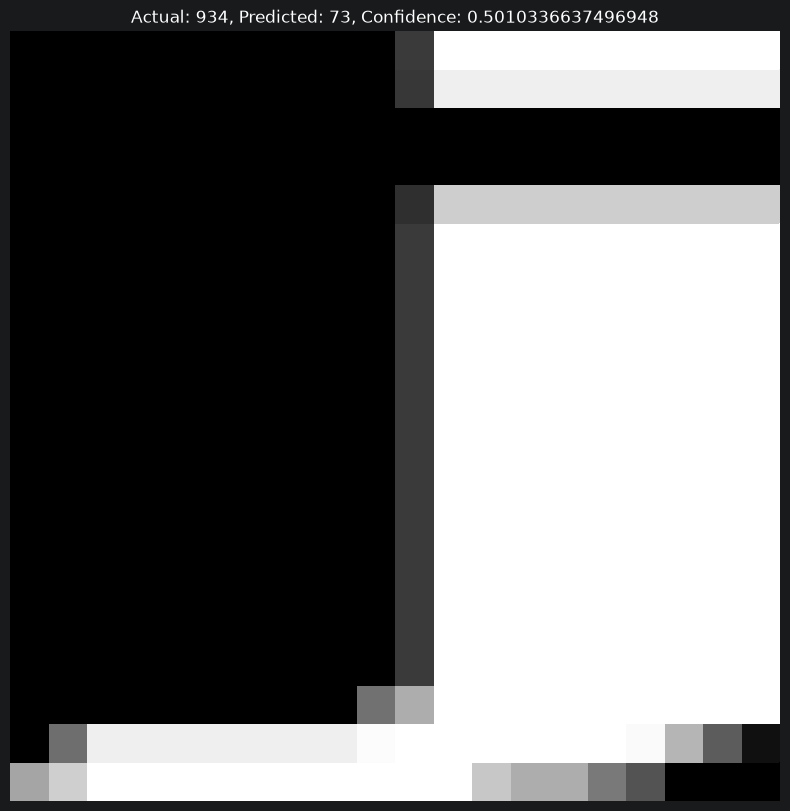

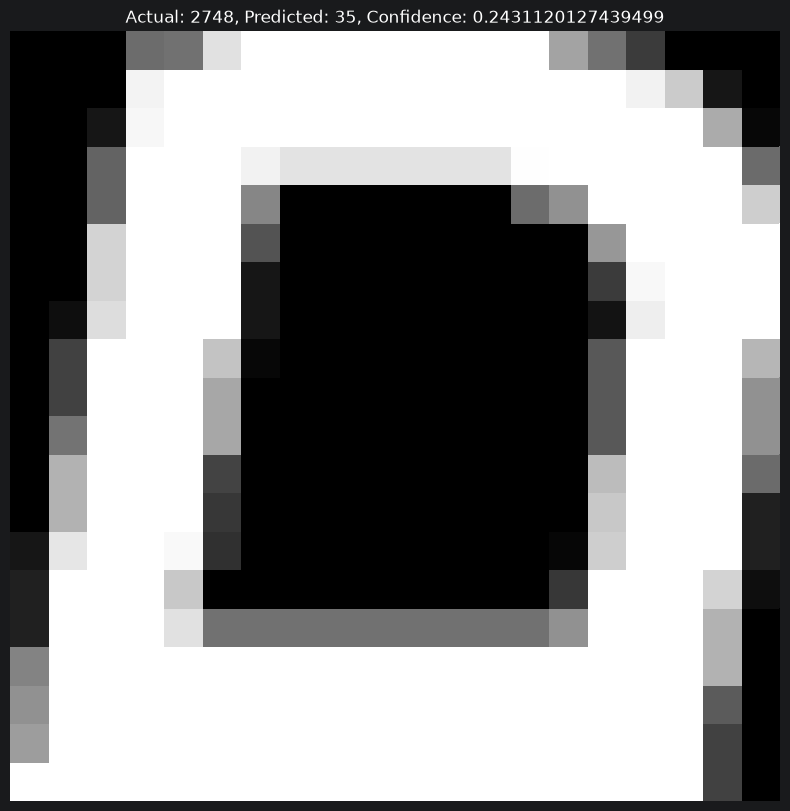

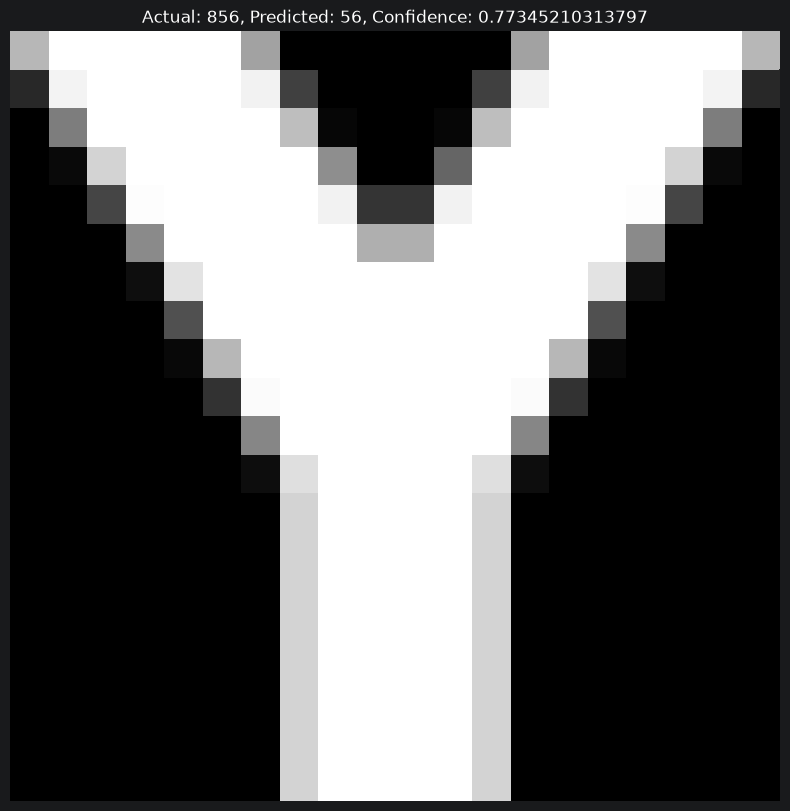

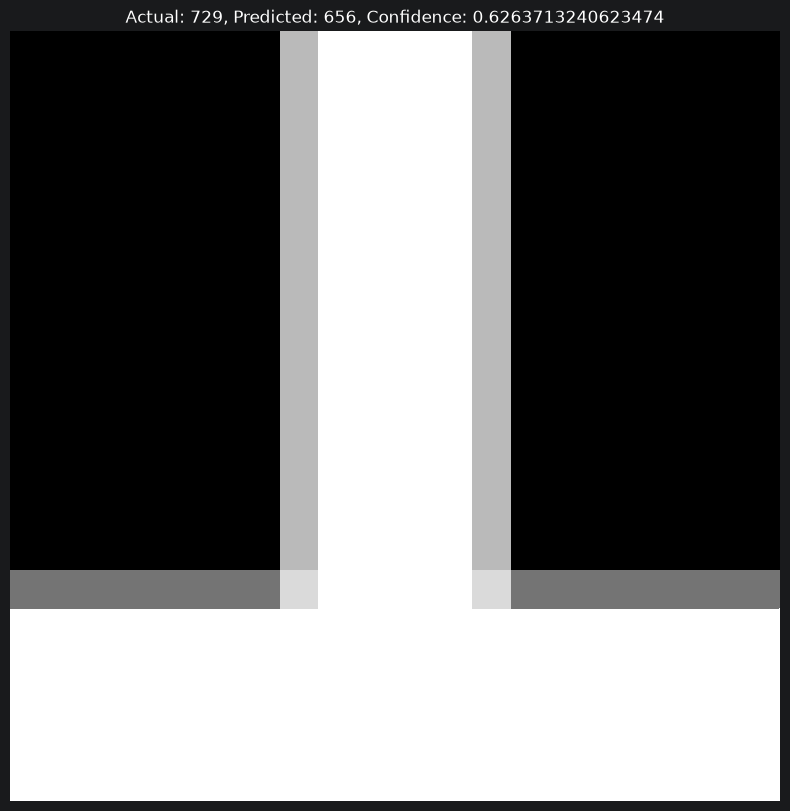

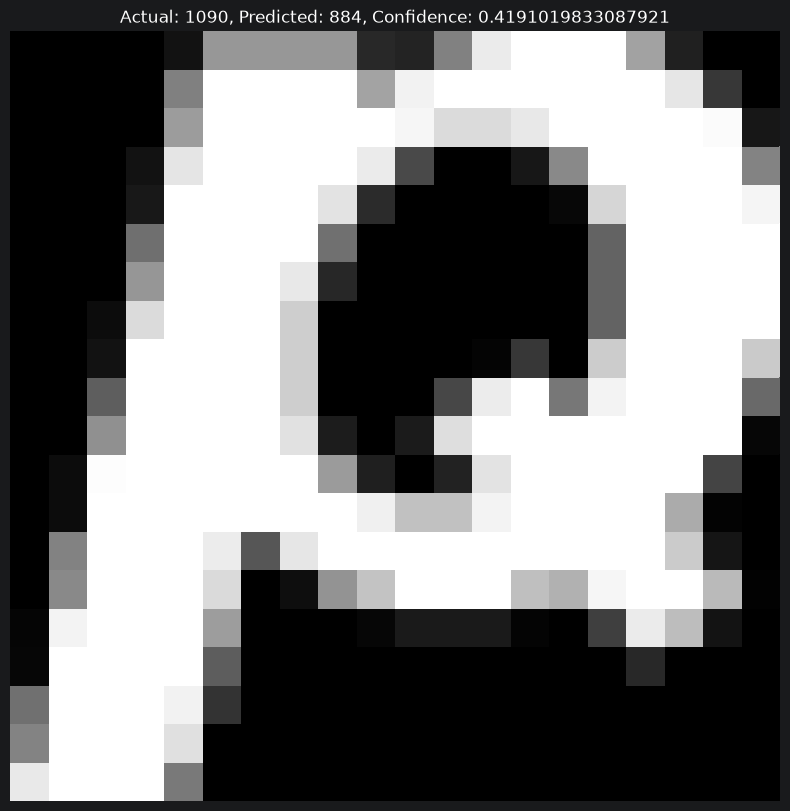

In [14]:
for image, actual, predicted, confidence in misses[:5]:
    plt.figure(figsize=(10, 10))
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"Actual: {actual}, Predicted: {predicted}, Confidence: {confidence}"
    )

    plt.axis("off")
    plt.show()

In [18]:
noise = np.random.normal(0, 0.2, combinedX.shape)
noisyImages = combinedX + noise
noisyImages = np.clip(noisyImages, 0, 1)

In [16]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(

            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [19]:
autoencoder = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

noisyTensor = torch.tensor(noisyImages, dtype=torch.float)
cleanTensor = torch.tensor(combinedX, dtype=torch.float)

dataset = TensorDataset(noisyTensor, cleanTensor)

trainLoader = DataLoader(dataset, batch_size=64, shuffle=True)

for epoch in range(10):
    autoencoder.train()
    runingLoss = 0

    for noisyBatch, cleanBatch in trainLoader:
        optimizer.zero_grad()
        outputs = autoencoder(noisyBatch)

        loss = criterion(outputs, cleanBatch)
        loss.backward()
        optimizer.step()
        runningLoss += loss.item()

    print(f"Epoch {epoch+1}: " f"Loss = {runningLoss:.4f}")

Epoch 1: Loss = 728.4530
Epoch 2: Loss = 737.4155
Epoch 3: Loss = 743.7833
Epoch 4: Loss = 749.6673
Epoch 5: Loss = 755.3202
Epoch 6: Loss = 760.8314
Epoch 7: Loss = 766.2534
Epoch 8: Loss = 771.6203
Epoch 9: Loss = 776.9496
Epoch 10: Loss = 782.2531


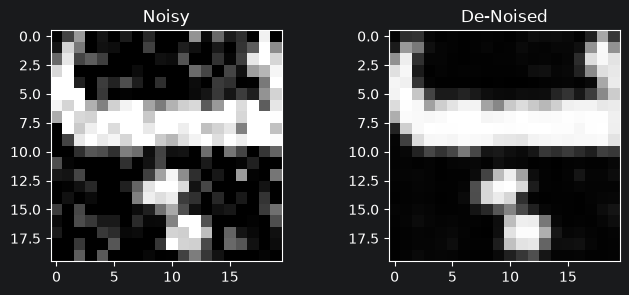

In [20]:
autoencoder.eval()

with torch.no_grad():
    reconstructed = autoencoder(noisyBatch)

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(noisyBatch[0].squeeze(), cmap="gray")
plt.title("Noisy")

plt.subplot(1,2,2)
plt.imshow(reconstructed[0].squeeze(), cmap="gray")
plt.title("De-Noised")

plt.show()